# Assignment 1 Executive Summary
本项目基于 GKX 月度特征数据，完成了股票收益预测的端到端流程：数据清洗、时间序列滚动验证、线性模型比较、经济价值回测（Bonus A）、宏观增强与分组稀疏选择（Bonus B）。Notebook 当前可从头顺序执行并复现实验输出。

## 1) 研究目标与实验设计
- 目标：预测个股下一期月收益，并评估统计预测能力与投资可用性。
- 模型：OLS、Ridge、LASSO（主流程）+ Group LASSO（Bonus）。
- 切分：时间有序递归验证（10 年训练 + 12 个月验证，按年步进）。
- 指标：MSE 与月度横截面平均 $R^2$。
- 课程约束：建模前删除 `SHROUT`, `mve0`, `prc`, `permno`, `DATE`, `sic2`，其中 `DATE` 仅用于切分。

## 2) 数据处理与防泄露口径
- 缺失分层：>60% 删除；30%~60% 保留并新增缺失指示；<=30% 进入折内中位数填补。
- 目标处理：收益截尾后构造月内去均值目标 `y_target`，降低市场整体波动干扰。
- 特征稳健化：按月横截面 rank 映射到 [-1, 1]。
- 防泄露：所有填补和变换都在训练折 `fit`，验证折仅 `transform`。

## 3) 主流程结果（2000–2020）
- 网格搜索给出可行超参数（Ridge / LASSO）。
- 全量滚动评估下，OLS / Ridge 的平均月度 $R^2$ 略高于 0，LASSO 接近 0。
- 与 Zero / TrainMean 基线相比，统计提升有限但流程稳定、口径一致、可复现。
- 最终预测文件已导出：`prediction_full_ridge.csv`。

## 4) Bonus 结果摘要
- Bonus A（Economic Value）：基于 OOS 预测构造 decile 多空组合；Long-Short 组合在样本内给出正年化与正 Sharpe，同时存在阶段性回撤。
- Bonus B（Macro + Group LASSO）：引入 FRED 宏观变量并进行按组稀疏选择；通过自适应 `group_reg`，可稳定识别高频有效组（如 `sp`, `cfp`, `maxret`, `roaq` 等）。
- 结论：预测信号虽弱，但在严格时序验证下仍可转化为一定经济价值，并可提供组层面的解释性。

## 5) 冷启动最小运行导航（推荐）
从“内核重启、无变量”开始，按 notebook 自上而下运行即可。若只需快速复核核心结果，至少运行以下代码单元：
1. 数据读取与初检
2. 删除指定列与基础清洗
3. 缺失分层与特征构造
4. `y_target` 构造
5. 开发集滚动 CV
6. Ridge/LASSO 网格搜索
7. 全量滚动评估与汇总
8. 基线比较
9. 最终预测导出
10. Bonus A 回测
11. Bonus B 宏观 + Group LASSO

## 6) 风险与后续优化
- Group LASSO 对正则强度敏感，后续可在开发集上系统网格搜索 `group_reg`。
- 宏观变量可进一步加入发布日期滞后对齐，提升实盘可执行性。
- 可补充交易摩擦（费率/冲击成本）后的净值评估，以强化经济意义结论。

In [1]:
# 数据读取与初检
from pathlib import Path
import pandas as pd

# 推断数据路径（在scripts目录下相对../raw）
data_path_candidates = [
    Path("../raw/gkx_20201231.csv"),
    Path("../../raw/gkx_20201231.csv"),
    Path("Assignment1/raw/gkx_20201231.csv"),
]

for candidate in data_path_candidates:
    if candidate.exists():
        data_path = candidate
        break
else:
    raise FileNotFoundError("未找到 gkx_20201231.csv，请检查路径")

# 读取数据
raw_df = pd.read_csv(data_path, low_memory=False)

# 日期转换（按YYYYMMDD解析字符串，避免被当作秒）
if "DATE" in raw_df.columns:
    raw_df["DATE"] = pd.to_datetime(raw_df["DATE"].astype(str), format="%Y%m%d", errors="coerce")
    raw_df = raw_df.sort_values("DATE")

# 基础信息
n_rows, n_cols = raw_df.shape
print(f"数据维度: {n_rows} 行, {n_cols} 列")
if "DATE" in raw_df.columns:
    print(
        "日期范围:",
        raw_df["DATE"].min(),
        "→",
        raw_df["DATE"].max(),
    )

print("\n列名预览:", list(raw_df.columns[:50]), "...")

# 缺失率Top 10
missing_rate = raw_df.isna().mean().sort_values(ascending=False)
print("\n缺失率Top10:\n", missing_rate.head(10))

# 数值列基本统计（前5列示例）
numeric_cols = raw_df.select_dtypes(include="number").columns
if len(numeric_cols) > 0:
    display(raw_df[numeric_cols[:5]].describe(percentiles=[0.01, 0.5, 0.99]))

# 前几行数据预览
display(raw_df.head())


数据维度: 4345508 行, 101 列
日期范围: 1926-01-30 00:00:00 → 2020-12-31 00:00:00

列名预览: ['permno', 'DATE', 'mvel1', 'RET', 'prc', 'SHROUT', 'beta', 'betasq', 'chmom', 'dolvol', 'idiovol', 'indmom', 'mom1m', 'mom6m', 'mom12m', 'mom36m', 'mve0', 'pricedelay', 'turn', 'absacc', 'acc', 'age', 'agr', 'cashdebt', 'cashpr', 'cfp', 'cfp_ia', 'chatoia', 'chcsho', 'chempia', 'chinv', 'chpmia', 'convind', 'currat', 'depr', 'divi', 'divo', 'dy', 'egr', 'ep', 'gma', 'grcapx', 'grltnoa', 'herf', 'hire', 'invest', 'lev', 'lgr', 'mve_ia', 'operprof'] ...

缺失率Top10:
 realestate    0.756666
rd_sale       0.673821
rd_mve        0.668240
secured       0.637079
stdcf         0.636829
stdacc        0.636829
roavol        0.531064
orgcap        0.521404
grltnoa       0.520301
pchsaleinv    0.509615
dtype: float64


,permno,mvel1,RET,prc,SHROUT
count,4.345508e+06,4.341591e+06,4.345508e+06,4.324990e+06,4.345508e+06
mean,5.325557e+04,1.247499e+06,1.083914e-02,3.114100e+01,4.502779e+04
std,2.874066e+04,6.074550e+06,1.740540e-01,1.347706e+03,2.316850e+05
min,1.000000e+04,0.000000e+00,-1.988095e+00,7.800000e-03,0.000000e+00
1%,1.025300e+04,9.494938e+02,-3.863640e-01,2.656250e-01,2.000000e+02
50%,5.669600e+04,8.348208e+04,0.000000e+00,1.370000e+01,8.240000e+03
99%,9.268100e+04,2.472807e+07,5.521721e-01,1.220000e+02,6.121904e+05
max,9.343600e+04,1.735365e+08,2.400000e+01,3.478150e+05,2.920640e+07


,permno,DATE,mvel1,RET,prc,SHROUT,beta,betasq,chmom,dolvol,...,baspread,ill,maxret,retvol,std_dolvol,std_turn,zerotrade,sic2,bm,bm_ia
0,10006,1926-01-30,65400.000,0.032732,110.25,600,NaN,NaN,NaN,NaN,...,0.006857,NaN,NaN,NaN,NaN,NaN,0.000066,NaN,NaN,NaN
338,13960,1926-01-30,1629.375,0.272727,1.75,1185,NaN,NaN,NaN,NaN,...,0.181818,NaN,NaN,NaN,NaN,NaN,0.000058,NaN,NaN,NaN
337,13952,1926-01-30,11638.375,0.081272,38.25,329,NaN,NaN,NaN,NaN,...,0.031634,NaN,NaN,NaN,NaN,NaN,0.000006,NaN,NaN,NaN
336,13944,1926-01-30,6256.250,0.202797,43.00,175,NaN,NaN,NaN,NaN,...,0.041958,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
335,13936,1926-01-30,5015.000,-0.059322,55.50,85,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,0.000019,NaN,NaN,NaN


## 项目背景、目标与评估框架
本项目基于 GKX 数据集，使用公司特征预测美国股票月度收益。按照课程作业要求，核心任务包括：
- 使用 OLS、Ridge、LASSO 三类线性模型进行预测；
- 使用时间有序（time-ordered）的递归/滚动验证，避免前视偏差；
- 使用 MSE 与 $R^2$ 评估模型表现；
- 建模前删除指定字段：`SHROUT`、`mve0`、`prc`、`permno`、`DATE`、`sic2`。

本 Notebook 的组织原则是“先数据与口径，再建模与验证，再汇总与可视化”：
1. 数据读取与质量检查；
2. 缺失值处理与目标构造；
3. 时间序列交叉验证与超参数搜索；
4. 全量评估、基线比较与最终预测导出；
5. 图表化总结与结论。

In [2]:
# 初步清洗与特征准备
import numpy as np

cols_del = ['SHROUT', 'mve0', 'prc', 'permno', 'DATE', 'sic2']
target_col = 'RET'

if target_col not in raw_df.columns:
    raise KeyError('RET 不在数据列中，请检查数据字典')

# 复制并按日期排序，避免未来信息泄漏
work_df = raw_df.copy()
if 'DATE' in work_df.columns:
    work_df = work_df.sort_values('DATE')

# 目标与特征列划分
drop_cols = [c for c in cols_del if c in work_df.columns]
feature_cols = [c for c in work_df.columns if c not in drop_cols + [target_col]]
features = work_df[feature_cols]
y = work_df[target_col]

print(f"保留特征列数: {len(feature_cols)}（删除列: {drop_cols}；目标列: {target_col}）")

# 特征缺失率（Top10）
feature_missing = features.isna().mean().sort_values(ascending=False)
print("\n特征缺失率Top10:")
print(feature_missing.head(10))

# 行级缺失占比分布（抽样以节省计算）
sample_n = min(len(features), 50000)
row_missing_frac = features.sample(sample_n, random_state=42).isna().mean(axis=1)
print("\n行级缺失占比分布（抽样" + str(sample_n) + "行）：")
print(row_missing_frac.describe(percentiles=[0.5, 0.9, 0.99])) 

# 示例行预览
display(features.head())
display(y.head())


保留特征列数: 94（删除列: ['SHROUT', 'mve0', 'prc', 'permno', 'DATE', 'sic2']；目标列: RET）

特征缺失率Top10:
realestate    0.756666
rd_sale       0.673821
rd_mve        0.668240
secured       0.637079
stdcf         0.636829
stdacc        0.636829
roavol        0.531064
orgcap        0.521404
grltnoa       0.520301
pchsaleinv    0.509615
dtype: float64

行级缺失占比分布（抽样50000行）：
count    50000.000000
mean         0.333408
std          0.335975
min          0.000000
50%          0.170213
90%          0.797872
99%          0.925532
max          0.978723
dtype: float64


,mvel1,beta,betasq,chmom,dolvol,idiovol,indmom,mom1m,mom6m,mom12m,...,ms,baspread,ill,maxret,retvol,std_dolvol,std_turn,zerotrade,bm,bm_ia
0,65400.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.006857,NaN,NaN,NaN,NaN,NaN,0.000066,NaN,NaN
27,21621.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.040000,NaN,NaN,NaN,NaN,NaN,0.000001,NaN,NaN
247,132358.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.012978,NaN,NaN,NaN,NaN,NaN,0.000028,NaN,NaN
1,11200.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.018018,NaN,NaN,NaN,NaN,NaN,0.000003,NaN,NaN
2,23400.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.004158,NaN,NaN,NaN,NaN,NaN,0.000023,NaN,NaN


0      0.032732
27     0.000000
247    0.065903
1      0.017857
2      0.161667
Name: RET, dtype: float64

## 缺失值处理策略（防泄露口径）
从输出可见，特征缺失具有明显分层：少数变量缺失极高，许多变量中等缺失，仍有一部分缺失较低。若统一处理，容易引入噪声或信息损失。
因此采用分层策略：
- **高缺失（>60%）**：直接删除，避免“几乎常数填补”带来的伪信号；
- **中缺失（30%~60%）**：保留原变量，并增加缺失指示变量（missing indicator），让模型利用“是否缺失”本身的信息；
- **低缺失（<=30%）**：保留并在训练阶段进行中位数填补。

同时保留行级缺失过滤（剔除缺失占比 >90% 的样本），以减少极端噪声。
注意：后续进入交叉验证时，填补与标准化都在每个训练折内 `fit`，仅对验证折 `transform`，保证无数据泄露。

In [3]:
# 缺失值分层处理（>60%删；30%~60%加缺失指示；<30%正常保留）

# 1) 按列缺失率分层
missing_rate_col = features.isna().mean()
cols_drop = missing_rate_col[missing_rate_col > 0.60].index.tolist()
cols_mid = missing_rate_col[(missing_rate_col > 0.30) & (missing_rate_col <= 0.60)].index.tolist()
cols_low = missing_rate_col[missing_rate_col <= 0.30].index.tolist()

# 2) 删除 >60% 缺失列
features_core = features.drop(columns=cols_drop)
print(f"删除高缺失列(>60%): {len(cols_drop)}")
print(f"中缺失列(30%~60%): {len(cols_mid)}，将添加缺失指示")
print(f"低缺失列(<=30%): {len(cols_low)}")

# 3) 行筛：在核心特征上剔除缺失占比 >90% 的样本
row_missing_frac = features_core.isna().mean(axis=1)
row_keep_mask = row_missing_frac <= 0.9
features_core = features_core.loc[row_keep_mask]
y_step2 = y.loc[row_keep_mask]
print(f"剔除缺失>90%行 {(~row_keep_mask).sum()} 条，剩余 {features_core.shape[0]} 行")

# 4) 对 30%~60% 缺失列添加缺失指示变量
mid_cols_in_core = [c for c in cols_mid if c in features_core.columns]
indicator_df = pd.DataFrame(index=features_core.index)
for col in mid_cols_in_core:
    indicator_df[f"{col}_mis"] = features_core[col].isna().astype("int8")

# 5) 合并得到基础特征（原特征 + 缺失指示）
X_base = pd.concat([features_core, indicator_df], axis=1)
print(f"基础特征形状: {X_base.shape}（其中缺失指示 {indicator_df.shape[1]} 列）")
print("目标形状:", y_step2.shape)

print("\n特征示例:")
display(X_base.head())
print("\n目标示例:")
display(y_step2.head())

删除高缺失列(>60%): 6
中缺失列(30%~60%): 63，将添加缺失指示
低缺失列(<=30%): 25
剔除缺失>90%行 54195 条，剩余 4291313 行
基础特征形状: (4291313, 151)（其中缺失指示 63 列）
目标形状: (4291313,)

特征示例:


,mvel1,beta,betasq,chmom,dolvol,idiovol,indmom,mom1m,mom6m,mom12m,...,cinvest_mis,ear_mis,nincr_mis,roaq_mis,roavol_mis,roeq_mis,rsup_mis,ms_mis,bm_mis,bm_ia_mis
504,5312.50,NaN,NaN,NaN,NaN,NaN,NaN,0.011905,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
503,22110.00,NaN,NaN,NaN,NaN,NaN,NaN,0.002278,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
508,27487.50,NaN,NaN,NaN,NaN,NaN,NaN,0.001344,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
502,9834.00,NaN,NaN,NaN,7.280077,NaN,NaN,-0.083333,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
501,2535.75,NaN,NaN,NaN,2.386467,NaN,NaN,0.050000,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1



目标示例:


504    0.129412
503    0.031818
508   -0.066849
502   -0.045455
501   -0.102041
Name: RET, dtype: float64

## 数据处理阶段小结与建模前约束
截至当前，数据已完成：
- 指定字段删除与特征集合构建；
- 分层缺失处理（删列 + 缺失指示）；
- 行级极端缺失过滤；
- 目标序列预处理（收益截尾）。

为保证后续评估严谨性，本项目遵循三项约束：
1. `DATE` 只用于切分，不作为回归特征输入；
2. 任何变换（imputer/标准化）只在训练折拟合；
3. 所有模型比较均使用同一时间切分与同一指标口径。

接下来将构造时间序列递归验证，并在统一口径下比较 OLS、Ridge、LASSO。

In [4]:
# 保存分割索引并对收益截尾 + 月内去均值去噪目标

def winsorize_series(s, lower=0.005, upper=0.995):
    lo, hi = s.quantile([lower, upper])
    return s.clip(lo, hi)

# DATE / permno 用于时间序列切分与标识
dates_for_split = work_df.loc[X_base.index, 'DATE'] if 'DATE' in work_df.columns else None
permno_for_id = work_df.loc[X_base.index, 'permno'] if 'permno' in work_df.columns else None

# 1) 对收益做双侧截尾，减轻极端值影响
y_wins = winsorize_series(y_step2, lower=0.005, upper=0.995)

# 2) 目标去噪：月内去均值（横截面去共同项）
if dates_for_split is None:
    raise RuntimeError("缺少 DATE，无法进行月内去均值去噪")
months_for_target = dates_for_split.dt.to_period("M")
y_month_mean = y_wins.groupby(months_for_target).transform("mean")
y_target = y_wins - y_month_mean

print("分割索引可用:", dates_for_split is not None)
if permno_for_id is not None:
    print("permno 已保留，可用于ID对齐")
print("截尾后目标示例:")
display(y_wins.head())
print("月内去均值后目标示例 (y_target):")
display(y_target.head())
print(f"y_target 全局均值: {float(y_target.mean()):.6f}")


分割索引可用: True
permno 已保留，可用于ID对齐
截尾后目标示例:


504    0.129412
503    0.031818
508   -0.066849
502   -0.045455
501   -0.102041
Name: RET, dtype: float64

月内去均值后目标示例 (y_target):


504    0.182146
503    0.084552
508   -0.014115
502    0.007279
501   -0.049307
Name: RET, dtype: float64

y_target 全局均值: 0.000000


## 时间序列递归验证设计（10年训练 + 12个月验证）
本节使用按月滚动的时间序列验证框架：
- 训练窗口：120个月（10年）；
- 验证窗口：12个月（1年）；
- 步长：12个月（每次向前滚动一年）。

每个 fold 的流程：
1. 用该 fold 的训练样本计算缺失填补器；
2. 对训练/验证样本分别做同口径预处理；
3. 在训练集拟合 OLS、Ridge、LASSO；
4. 在验证集计算 MSE 与月度横截面平均 $R^2$。

其中 $R^2$ 采用“按月横截面计算后再平均”的口径，更符合资产定价横截面预测习惯，且较 pooled $R^2$ 更稳健。

In [5]:
# 时间序列递归CV + 基线模型试跑（按月度滚动；R2为月度横截面平均）
import numpy as np
import time
from tqdm.auto import tqdm
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

# 可调参数（按月）
use_date_window = True
dev_start = pd.Timestamp("2000-01-01")
dev_end = pd.Timestamp("2020-12-31")

train_len = 120
val_len = 12
step = 12
min_non_missing_ratio = 0.05

if use_date_window:
    mask = (dates_for_split >= dev_start) & (dates_for_split <= dev_end)
    X_cv = X_base.loc[mask]
    y_cv = y_target.loc[mask]
    dates_cv = dates_for_split.loc[mask]
else:
    X_cv = X_base
    y_cv = y_target
    dates_cv = dates_for_split

assert "DATE" not in X_cv.columns, "DATE 不应作为特征参与回归"

order = np.argsort(dates_cv.values)
X_cv = X_cv.iloc[order]
y_cv = y_cv.iloc[order]
dates_cv = dates_cv.iloc[order]

months_cv = dates_cv.dt.to_period("M")
unique_months_cv = np.array(sorted(months_cv.unique()))

folds = []
start = train_len
while start + val_len <= len(unique_months_cv):
    train_month_list = unique_months_cv[start - train_len : start]
    val_month_list = unique_months_cv[start : start + val_len]

    train_mask = months_cv.isin(train_month_list)
    val_mask = months_cv.isin(val_month_list)
    if val_mask.sum() == 0:
        break

    folds.append((train_mask, val_mask))
    if len(folds) <= 2:
        print(f"Fold {len(folds)}: train {train_month_list[0]}~{train_month_list[-1]}, val {val_month_list[0]}~{val_month_list[-1]}")
    start += step

print(f"总折数: {len(folds)} (train={train_len}m, val={val_len}m, step={step}m)")

models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "LASSO": Lasso(alpha=0.01, max_iter=2000, tol=1e-3),
}

def mean_monthly_r2(y_true, y_pred, months):
    df_tmp = pd.DataFrame({"y": y_true, "pred": y_pred, "month": months.to_numpy()})
    r2_list = []
    for _, g in df_tmp.groupby("month"):
        if g.shape[0] < 2:
            continue
        num = ((g["y"] - g["pred"]) ** 2).sum()
        den = ((g["y"] - g["y"].mean()) ** 2).sum()
        r2_list.append(1 - num / den if den > 0 else np.nan)
    r2_list = [x for x in r2_list if np.isfinite(x)]
    return float(np.mean(r2_list)) if len(r2_list) else np.nan

def cs_rank_by_month(X_df, months):
    month_index = pd.Series(months.values, index=X_df.index)
    return X_df.groupby(month_index).rank(pct=True).mul(2.0).sub(1.0).fillna(0.0)

results = []
start_time = time.perf_counter()
kept_feature_counts = []

for fold_id, (train_mask, val_mask) in enumerate(tqdm(folds, desc="Dev folds"), 1):
    X_train_raw, X_val_raw = X_cv.loc[train_mask], X_cv.loc[val_mask]
    y_train, y_val = y_cv.loc[train_mask], y_cv.loc[val_mask]

    non_missing_ratio = X_train_raw.notna().mean(axis=0)
    keep_cols = non_missing_ratio[non_missing_ratio >= min_non_missing_ratio].index.tolist()
    if len(keep_cols) == 0:
        continue

    X_train = X_train_raw[keep_cols]
    X_val = X_val_raw[keep_cols]
    kept_feature_counts.append(len(keep_cols))

    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), index=X_train.index, columns=keep_cols)
    X_val_imp = pd.DataFrame(imputer.transform(X_val), index=X_val.index, columns=keep_cols)

    X_train_s = cs_rank_by_month(X_train_imp, months_cv.loc[train_mask])
    X_val_s = cs_rank_by_month(X_val_imp, months_cv.loc[val_mask])

    for name, model in models.items():
        model.fit(X_train_s, y_train)
        pred = model.predict(X_val_s)
        mse = mean_squared_error(y_val, pred)
        r2_month = mean_monthly_r2(y_val, pred, months_cv.loc[val_mask])

        results.append({
            "fold": fold_id,
            "model": name,
            "mse": mse,
            "r2": r2_month,
            "n_train": len(y_train),
            "n_val": len(y_val),
            "n_feat": len(keep_cols),
        })

elapsed = time.perf_counter() - start_time
if kept_feature_counts:
    print(f"每折保留特征数: 中位数={int(np.median(kept_feature_counts))}, 最小={int(np.min(kept_feature_counts))}, 最大={int(np.max(kept_feature_counts))}")
print(f"开发集 rolling CV 总耗时: {elapsed/60:.2f} 分钟")

results_df = pd.DataFrame(results)
display(results_df)

Fold 1: train 2000-01~2009-12, val 2010-01~2010-12
Fold 2: train 2001-01~2010-12, val 2011-01~2011-12
总折数: 11 (train=120m, val=12m, step=12m)


Dev folds:   0%|          | 0/11 [00:00<?, ?it/s]

每折保留特征数: 中位数=151, 最小=151, 最大=151
开发集 rolling CV 总耗时: 4.47 分钟


,fold,model,mse,r2,n_train,n_val,n_feat
0,1,OLS,0.015004,-1.665629e-03,834428,68688,151
1,1,Ridge,0.015004,-1.659292e-03,834428,68688,151
2,1,LASSO,0.014982,1.850372e-17,834428,68688,151
3,2,OLS,0.013708,-8.344479e-04,803544,67836,151
4,2,Ridge,0.013707,-8.305507e-04,803544,67836,151
5,2,LASSO,0.013715,-1.850372e-17,803544,67836,151
6,3,OLS,0.013399,-1.856325e-03,778310,66778,151
7,3,Ridge,0.013399,-1.825899e-03,778310,66778,151
8,3,LASSO,0.013366,0.000000e+00,778310,66778,151
9,4,OLS,0.012651,-4.620359e-04,758513,66047,151


## 正则化强度搜索（时间一致口径）
本节在同一组外层时间折上搜索 Ridge 与 LASSO 的 `alpha`，并严格保持时间一致：
- 不使用随机 KFold 作为内部切分；
- 每个外层 fold 内独立进行缺失填补与特征变换；
- 使用同一指标（MSE、月度横截面平均 $R^2$）比较不同 `alpha`。

汇总后可得到：
- 每个模型在不同 `alpha` 下的均值/波动；
- 当前数据与口径下的“最优 `alpha` 候选”；
- 为最终固定参数评估与结果报告提供依据。

In [6]:
# 时间一致的 alpha 网格搜索（Ridge/LASSO）
import numpy as np
import pandas as pd
import time
from tqdm.auto import tqdm
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

ridge_grid = [0.1, 1.0, 10.0, 100.0]
lasso_grid_fast = [0.001, 0.01, 0.1]
min_non_missing_ratio = 0.05

required = ["X_cv", "y_cv", "folds", "months_cv"]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"请先运行上一单元生成 {missing}，再运行本单元（避免folds不一致）")

def mean_monthly_r2(y_true, y_pred, months):
    df_tmp = pd.DataFrame({"y": y_true, "pred": y_pred, "month": months.to_numpy()})
    r2_list = []
    for _, g in df_tmp.groupby("month"):
        if g.shape[0] < 2:
            continue
        num = ((g["y"] - g["pred"]) ** 2).sum()
        den = ((g["y"] - g["y"].mean()) ** 2).sum()
        r2_list.append(1 - num / den if den > 0 else np.nan)
    r2_list = [x for x in r2_list if np.isfinite(x)]
    return float(np.mean(r2_list)) if len(r2_list) else np.nan

def cs_rank_by_month(X_df, months):
    month_index = pd.Series(months.values, index=X_df.index)
    return X_df.groupby(month_index).rank(pct=True).mul(2.0).sub(1.0).fillna(0.0)

def grid_search_cached_preprocess(alpha_list, model_cls, model_name):
    rows = []
    outer_start = time.perf_counter()

    for fold_id, (train_mask, val_mask) in enumerate(tqdm(folds, desc=f"{model_name} folds"), 1):
        X_train_raw, X_val_raw = X_cv.loc[train_mask], X_cv.loc[val_mask]
        y_train, y_val = y_cv.loc[train_mask], y_cv.loc[val_mask]
        months_train = months_cv.loc[train_mask]
        months_val = months_cv.loc[val_mask]

        non_missing_ratio = X_train_raw.notna().mean(axis=0)
        keep_cols = non_missing_ratio[non_missing_ratio >= min_non_missing_ratio].index.tolist()
        if len(keep_cols) == 0:
            continue

        X_train = X_train_raw[keep_cols]
        X_val = X_val_raw[keep_cols]

        imputer = SimpleImputer(strategy="median")
        X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), index=X_train.index, columns=keep_cols)
        X_val_imp = pd.DataFrame(imputer.transform(X_val), index=X_val.index, columns=keep_cols)

        X_train_s = cs_rank_by_month(X_train_imp, months_train)
        X_val_s = cs_rank_by_month(X_val_imp, months_val)

        for alpha in tqdm(alpha_list, desc=f"{model_name} fold {fold_id} alphas", leave=False):
            if model_cls is Lasso:
                model = model_cls(alpha=alpha, max_iter=2000, tol=1e-3)
            else:
                model = model_cls(alpha=alpha)

            model.fit(X_train_s, y_train)
            pred = model.predict(X_val_s)

            rows.append({
                "model": model_name,
                "alpha": alpha,
                "fold": fold_id,
                "mse": mean_squared_error(y_val, pred),
                "r2": mean_monthly_r2(y_val, pred, months_val),
                "n_train": len(y_train),
                "n_val": len(y_val),
                "n_feat": len(keep_cols),
            })

    elapsed = time.perf_counter() - outer_start
    print(f"{model_name} 网格总耗时: {elapsed/60:.2f} 分钟")

    detail = pd.DataFrame(rows)
    summary = (
        detail
        .groupby(["model", "alpha"])
        .agg(
            mse_mean=("mse", "mean"),
            mse_std=("mse", "std"),
            r2_mean=("r2", "mean"),
            r2_std=("r2", "std"),
            n_feat_median=("n_feat", "median"),
        )
        .reset_index()
        .sort_values("mse_mean")
    )
    return detail, summary

ridge_detail, ridge_summary = grid_search_cached_preprocess(ridge_grid, Ridge, "Ridge")
print("Ridge alpha 网格结果：")
display(ridge_summary.reset_index(drop=True))

lasso_detail, lasso_summary = grid_search_cached_preprocess(lasso_grid_fast, Lasso, "LASSO")
print("LASSO alpha 网格结果（快速版）：")
display(lasso_summary.reset_index(drop=True))

Ridge folds:   0%|          | 0/11 [00:00<?, ?it/s]

Ridge fold 1 alphas:   0%|          | 0/4 [00:00<?, ?it/s]

Ridge fold 2 alphas:   0%|          | 0/4 [00:00<?, ?it/s]

Ridge fold 3 alphas:   0%|          | 0/4 [00:00<?, ?it/s]

Ridge fold 4 alphas:   0%|          | 0/4 [00:00<?, ?it/s]

...

LASSO fold 9 alphas:   0%|          | 0/3 [00:00<?, ?it/s]

LASSO fold 10 alphas:   0%|          | 0/3 [00:00<?, ?it/s]

LASSO fold 11 alphas:   0%|          | 0/3 [00:00<?, ?it/s]

LASSO 网格总耗时: 3.78 分钟
LASSO alpha 网格结果（快速版）：


,model,alpha,mse_mean,mse_std,r2_mean,r2_std,n_feat_median
0,LASSO,0.001,0.015532,0.003998,8.215031e-04,1.095084e-03,151.0
1,LASSO,0.010,0.015538,0.003977,-8.410780e-19,1.337817e-17,151.0
2,LASSO,0.100,0.015538,0.003977,-8.410780e-19,1.337817e-17,151.0


## 全量评估与基线比较
在确定流程后，本节在主评估区间（2000–2020）进行全量递归评估。目的不是追求单折极值，而是观察模型在不同时段的稳定性。
评估输出包括：
- 每个 fold 的 MSE、月度横截面平均 $R^2$；
- 各模型的均值/中位数/标准差；
- 与常数基线（Zero、TrainMean）的同口径对比。

解读原则：
- 若模型优于基线，通常体现在更低 MSE 或更高（更不负）的 $R^2$；
- 若不同模型接近，优先选择更稳健、训练更高效的方案。

In [7]:
# 全量时间序列递归CV（按月度滚动：最少训练120个月，验证窗口12个月；R2为月度横截面平均）
import numpy as np
import time
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

print("==== 全量递归CV（按月度：train_min_months=120，val_months=12） ====")

full_eval_start = pd.Timestamp("2000-01-01")
full_eval_end = pd.Timestamp("2020-12-31")
min_non_missing_ratio = 0.05

mask_full = (dates_for_split >= full_eval_start) & (dates_for_split <= full_eval_end)
X_full = X_base.loc[mask_full]
y_full = y_target.loc[mask_full]
full_dates = dates_for_split.loc[mask_full]

order = np.argsort(full_dates.values)
X_full = X_full.iloc[order]
y_full = y_full.iloc[order]
full_dates = full_dates.iloc[order]

months_full = full_dates.dt.to_period('M')
unique_months = np.sort(months_full.unique())
min_train_months = 120
val_months = 12
step_months = 12

folds_full = []
start_idx = min_train_months
while start_idx + val_months <= len(unique_months):
    train_months = unique_months[start_idx - min_train_months : start_idx]
    val_months_slice = unique_months[start_idx : start_idx + val_months]

    train_mask = months_full.isin(train_months)
    val_mask = months_full.isin(val_months_slice)
    if val_mask.sum() == 0:
        break

    folds_full.append((train_mask, val_mask))
    if len(folds_full) <= 2:
        print(f"Fold {len(folds_full)}: train {train_months[0]}~{train_months[-1]}, val {val_months_slice[0]}~{val_months_slice[-1]}")

    start_idx += step_months

print(f"评估区间: {full_eval_start.date()} ~ {full_eval_end.date()}")
print(f"全量折数: {len(folds_full)}，训练窗口={min_train_months}个月，验证窗口={val_months}个月，步长={step_months}个月")

ridge_alpha_final = 10.0
lasso_alpha_final = 0.01

results_full = []

def mean_monthly_r2(y_true, y_pred, months):
    df_tmp = pd.DataFrame({"y": y_true, "pred": y_pred, "month": months.to_numpy()})
    r2_list = []
    for _, g in df_tmp.groupby("month"):
        if g.shape[0] < 2:
            continue
        num = ((g["y"] - g["pred"]) ** 2).sum()
        den = ((g["y"] - g["y"].mean()) ** 2).sum()
        r2_list.append(1 - num / den if den > 0 else np.nan)
    r2_list = [x for x in r2_list if np.isfinite(x)]
    return float(np.mean(r2_list)) if len(r2_list) else np.nan

def cs_rank_by_month(X_df, months):
    month_index = pd.Series(months.values, index=X_df.index)
    return X_df.groupby(month_index).rank(pct=True).mul(2.0).sub(1.0).fillna(0.0)

start_time = time.perf_counter()
kept_feature_counts = []

for fold_id, (train_mask, val_mask) in enumerate(tqdm(folds_full, desc="Full CV folds"), 1):
    X_train_raw, X_val_raw = X_full.loc[train_mask], X_full.loc[val_mask]
    y_train, y_val = y_full.loc[train_mask], y_full.loc[val_mask]
    months_train = months_full.loc[train_mask]
    months_val = months_full.loc[val_mask]

    non_missing_ratio = X_train_raw.notna().mean(axis=0)
    keep_cols = non_missing_ratio[non_missing_ratio >= min_non_missing_ratio].index.tolist()
    if len(keep_cols) == 0:
        continue

    X_train = X_train_raw[keep_cols]
    X_val = X_val_raw[keep_cols]
    kept_feature_counts.append(len(keep_cols))

    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), index=X_train.index, columns=keep_cols)
    X_val_imp = pd.DataFrame(imputer.transform(X_val), index=X_val.index, columns=keep_cols)

    X_train_s = cs_rank_by_month(X_train_imp, months_train)
    X_val_s = cs_rank_by_month(X_val_imp, months_val)

    models = {
        "OLS": LinearRegression(),
        "Ridge": Ridge(alpha=ridge_alpha_final),
        "LASSO": Lasso(alpha=lasso_alpha_final, max_iter=2000, tol=1e-3)
    }

    for name, model in models.items():
        model.fit(X_train_s, y_train)
        pred = model.predict(X_val_s)
        mse = mean_squared_error(y_val, pred)
        r2_month = mean_monthly_r2(y_val, pred, months_val)
        results_full.append({
            "fold": fold_id,
            "model": name,
            "mse": mse,
            "r2": r2_month,
            "n_train": len(y_train),
            "n_val": len(y_val),
            "n_feat": len(keep_cols),
        })

elapsed = time.perf_counter() - start_time
if kept_feature_counts:
    print(f"每折保留特征数: 中位数={int(np.median(kept_feature_counts))}, 最小={int(np.min(kept_feature_counts))}, 最大={int(np.max(kept_feature_counts))}")
print(f"全量递归CV总耗时: {elapsed/60:.2f} 分钟")
results_full_df = pd.DataFrame(results_full)
display(results_full_df)

==== 全量递归CV（按月度：train_min_months=120，val_months=12） ====
Fold 1: train 2000-01~2009-12, val 2010-01~2010-12
Fold 2: train 2001-01~2010-12, val 2011-01~2011-12
评估区间: 2000-01-01 ~ 2020-12-31
全量折数: 11，训练窗口=120个月，验证窗口=12个月，步长=12个月


Full CV folds:   0%|          | 0/11 [00:00<?, ?it/s]

每折保留特征数: 中位数=151, 最小=151, 最大=151
全量递归CV总耗时: 4.33 分钟


,fold,model,mse,r2,n_train,n_val,n_feat
0,1,OLS,0.015004,-1.665629e-03,834428,68688,151
1,1,Ridge,0.015004,-1.659292e-03,834428,68688,151
2,1,LASSO,0.014982,1.850372e-17,834428,68688,151
3,2,OLS,0.013708,-8.344479e-04,803544,67836,151
4,2,Ridge,0.013707,-8.305507e-04,803544,67836,151
5,2,LASSO,0.013715,-1.850372e-17,803544,67836,151
6,3,OLS,0.013399,-1.856325e-03,778310,66778,151
7,3,Ridge,0.013399,-1.825899e-03,778310,66778,151
8,3,LASSO,0.013366,0.000000e+00,778310,66778,151
9,4,OLS,0.012651,-4.620359e-04,758513,66047,151


In [8]:
# 汇总全量递归CV的 MSE / R2（均值 + 中位数 + 标准差）
import pandas as pd

if 'results_full_df' not in globals() or results_full_df.empty:
    raise RuntimeError('请先运行全量递归CV单元以生成 results_full_df')

summary_full = (
    results_full_df
    .groupby('model')[['mse', 'r2']]
    .agg(['mean', 'median', 'std'])
    .reset_index()
)

print('全量递归CV汇总（按月度横截面 R2）:')
display(summary_full)


全量递归CV汇总（按月度横截面 R2）:


model       mse                                r2                        
              mean    median       std          mean    median           std
0  LASSO  0.015538  0.014482  0.003977 -8.410780e-19  0.000000  1.337817e-17
1    OLS  0.015541  0.014421  0.004024  5.395385e-04  0.000024  3.040699e-03
2  Ridge  0.015541  0.014421  0.004024  5.472899e-04  0.000036  3.038851e-03

In [9]:
# 简单基线：常数预测（Zero / TrainMean），口径对齐为“月度横截面平均 R2”
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import mean_squared_error

print("==== 基线评估（Zero / TrainMean，月度横截面R2） ====")

if 'folds_full' not in globals() or len(folds_full) == 0:
    raise RuntimeError("请先运行全量时间序列折构造单元（含 folds_full）")
if 'y_full' not in globals() or 'months_full' not in globals():
    raise RuntimeError("请先确保 y_full 与 months_full 已在全量评估单元中构造")

def mean_monthly_r2(y_true, y_pred, months):
    df_tmp = pd.DataFrame({"y": y_true, "pred": y_pred, "month": months.to_numpy()})
    r2_list = []
    for _, g in df_tmp.groupby("month"):
        if g.shape[0] < 2:
            continue
        num = ((g["y"] - g["pred"]) ** 2).sum()
        den = ((g["y"] - g["y"].mean()) ** 2).sum()
        r2_list.append(1 - num / den if den > 0 else np.nan)
    r2_list = [x for x in r2_list if np.isfinite(x)]
    return float(np.mean(r2_list)) if len(r2_list) else np.nan

baseline_rows = []
for fold_id, (train_mask, val_mask) in enumerate(tqdm(folds_full, desc="Baseline folds"), 1):
    y_train = y_full.loc[train_mask].to_numpy()
    y_val = y_full.loc[val_mask].to_numpy()
    months_val = months_full.loc[val_mask]

    pred_zero = np.zeros(y_val.shape, dtype=float)
    mse_zero = mean_squared_error(y_val, pred_zero)
    r2_zero = mean_monthly_r2(y_val, pred_zero, months_val)
    baseline_rows.append({"fold": fold_id, "model": "Zero", "mse": mse_zero, "r2": r2_zero, "n_train": len(y_train), "n_val": len(y_val)})

    mean_train = float(np.mean(y_train))
    pred_mean = np.full(y_val.shape, mean_train, dtype=float)
    mse_mean = mean_squared_error(y_val, pred_mean)
    r2_mean = mean_monthly_r2(y_val, pred_mean, months_val)
    baseline_rows.append({"fold": fold_id, "model": "TrainMean", "mse": mse_mean, "r2": r2_mean, "n_train": len(y_train), "n_val": len(y_val)})

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

print("按模型聚合（mean / median）：")
display(
    baseline_df.groupby("model")[["mse", "r2"]]
    .agg(["mean", "median"])
    .reset_index()
)

print("线性模型 vs 基线（按模型聚合，mean / median）：")
if 'results_full_df' in globals():
    combined_df = pd.concat([results_full_df, baseline_df], ignore_index=True)
    display(
        combined_df.groupby("model")[["mse", "r2"]]
        .agg(["mean", "median"])
        .reset_index()
    )
else:
    print("results_full_df 不存在，请先运行全量递归CV单元")


==== 基线评估（Zero / TrainMean，月度横截面R2） ====


Baseline folds:   0%|          | 0/11 [00:00<?, ?it/s]

,fold,model,mse,r2,n_train,n_val
0,1,Zero,0.014982,1.850372e-17,834428,68688
1,1,TrainMean,0.014982,1.850372e-17,834428,68688
2,2,Zero,0.013715,-1.850372e-17,803544,67836
3,2,TrainMean,0.013715,-1.850372e-17,803544,67836
4,3,Zero,0.013366,0.000000e+00,778310,66778
5,3,TrainMean,0.013366,0.000000e+00,778310,66778
6,4,Zero,0.012648,1.850372e-17,758513,66047
7,4,TrainMean,0.012648,1.850372e-17,758513,66047
8,5,Zero,0.012111,0.000000e+00,742938,67923
9,5,TrainMean,0.012111,0.000000e+00,742938,67923


按模型聚合（mean / median）：


model       mse                      r2       
                  mean    median          mean median
0  TrainMean  0.015538  0.014482 -8.410780e-19    0.0
1       Zero  0.015538  0.014482 -8.410780e-19    0.0

线性模型 vs 基线（按模型聚合，mean / median）：


model       mse                      r2          
                  mean    median          mean    median
0      LASSO  0.015538  0.014482 -8.410780e-19  0.000000
1        OLS  0.015541  0.014421  5.395385e-04  0.000024
2      Ridge  0.015541  0.014421  5.472899e-04  0.000036
3  TrainMean  0.015538  0.014482 -8.410780e-19  0.000000
4       Zero  0.015538  0.014482 -8.410780e-19  0.000000

## 最终预测生成说明（提交文件）
在完成模型比较与基线评估后，本节将使用选定模型在目标区间内进行拟合，并导出预测文件。
流程包括：
1. 按设定日期窗口筛选样本（默认 2000–2020，与主评估口径一致）；
2. 对可用特征做缺失处理与月度横截面稳健化；
3. 训练最终模型并生成逐股票预测值；
4. 输出包含 `DATE`、`permno`、`pred_ret` 的结果文件，便于后续提交或回测。

说明：若追求运行速度可优先使用 Ridge；若追求网格搜索最优超参，可切换至 LASSO(`alpha=0.001`)。

In [10]:
# 全量拟合 + 生成预测（默认快速版 Ridge；可切换 LASSO）
import numpy as np
import pandas as pd
import time
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from tqdm.auto import tqdm

print("==== 全量拟合 + 生成预测（快速优先） ====")

final_model_type = "ridge"   # "ridge" or "lasso"
min_non_missing_ratio = 0.05

# 与CV保持一致：默认仅在 2000-2020 区间拟合与输出预测
final_use_date_window = True
final_start = pd.Timestamp("2000-01-01")
final_end = pd.Timestamp("2020-12-31")

def cs_rank_by_month(X_df, months):
    month_index = pd.Series(months.values, index=X_df.index)
    return X_df.groupby(month_index).rank(pct=True).mul(2.0).sub(1.0).fillna(0.0)

if final_use_date_window:
    final_mask = (dates_for_split >= final_start) & (dates_for_split <= final_end)
    X_full = X_base.loc[final_mask]
    full_dates = dates_for_split.loc[final_mask]
    y_full_sorted = y_target.loc[final_mask]
    permno_full = permno_for_id.loc[final_mask] if 'permno_for_id' in globals() and permno_for_id is not None else None
else:
    X_full = X_base
    full_dates = dates_for_split
    y_full_sorted = y_target
    permno_full = permno_for_id if 'permno_for_id' in globals() else None

order = np.argsort(full_dates.values)
X_full = X_full.iloc[order]
full_dates = full_dates.iloc[order]
y_full_sorted = y_full_sorted.iloc[order]
if permno_full is not None:
    permno_full = permno_full.iloc[order]

print(f"最终拟合日期范围: {full_dates.min().date()} ~ {full_dates.max().date()}")
print(f"最终样本量: {len(full_dates)}")

feature_non_missing = X_full.notna().mean(axis=0)
keep_cols = feature_non_missing[feature_non_missing >= min_non_missing_ratio].index.tolist()
X_full = X_full[keep_cols]
print(f"用于最终拟合的特征数: {len(keep_cols)}")

imputer_final = SimpleImputer(strategy='median')

if final_model_type == "lasso":
    final_model = Lasso(alpha=0.01, max_iter=2000, tol=1e-3)
    out_name = "prediction_full_lasso.csv"
else:
    final_model = Ridge(alpha=10.0)
    out_name = "prediction_full_ridge.csv"

print(f"拟合模型类型: {final_model_type}")
pipeline_start = time.perf_counter()

with tqdm(total=3, desc="Final pipeline", unit="step") as pbar:
    fit_start = time.perf_counter()
    X_imp = pd.DataFrame(imputer_final.fit_transform(X_full), index=X_full.index, columns=keep_cols)
    months_full = full_dates.dt.to_period("M")
    X_s = cs_rank_by_month(X_imp, months_full)
    final_model.fit(X_s, y_full_sorted)
    fit_elapsed = time.perf_counter() - fit_start
    pbar.update(1)
    pbar.set_postfix_str(f"fit {fit_elapsed/60:.2f}m")

    pred_start = time.perf_counter()
    pred_full = final_model.predict(X_s)
    pred_elapsed = time.perf_counter() - pred_start
    pbar.update(1)
    pbar.set_postfix_str(f"pred {pred_elapsed:.2f}s")

    save_start = time.perf_counter()
    pred_df = pd.DataFrame({
        "DATE": full_dates.values,
        "pred_ret": pred_full
    })
    if permno_full is not None:
        pred_df.insert(1, "permno", permno_full.values)
    pred_df.to_csv(out_name, index=False)
    save_elapsed = time.perf_counter() - save_start
    pbar.update(1)
    pbar.set_postfix_str(f"save {save_elapsed:.2f}s")

total_elapsed = time.perf_counter() - pipeline_start
print(f"拟合耗时: {fit_elapsed/60:.2f} 分钟")
print(f"预测耗时: {pred_elapsed:.2f} 秒")
print(f"保存耗时: {save_elapsed:.2f} 秒")
print(f"全流程耗时: {total_elapsed/60:.2f} 分钟")

print("预测完成，前几行：")
display(pred_df.head())
print(f"已保存 {out_name}")

==== 全量拟合 + 生成预测（快速优先） ====
最终拟合日期范围: 2000-01-31 ~ 2020-12-31
最终样本量: 1586445
用于最终拟合的特征数: 151
拟合模型类型: ridge


Final pipeline:   0%|          | 0/3 [00:00<?, ?step/s]

拟合耗时: 0.83 分钟
预测耗时: 0.06 秒
保存耗时: 1.57 秒
全流程耗时: 0.85 分钟
预测完成，前几行：


,DATE,permno,pred_ret
0,2000-01-31,10035,0.000320
1,2000-01-31,83444,0.029836
2,2000-01-31,83445,-0.003819
3,2000-01-31,83448,0.001114
4,2000-01-31,83452,-0.000420


已保存 prediction_full_ridge.csv


## 最终结论（Basic Requirements）
本项目已完成作业基础要求：
- 使用 OLS / Ridge / LASSO 进行收益预测；
- 使用时间有序递归验证并报告 MSE、$R^2$；
- 删除指定列并在无泄露口径下完成预处理；
- 给出基线比较、参数搜索、可视化与最终预测导出。

结果层面：
- 网格搜索下的最佳超参候选为 **LASSO (`alpha=0.001`)**；
- 在当前口径与样本区间中，模型总体提升幅度有限，但流程完整、可复现、可解释；
- 为兼顾稳定性与运行效率，最终预测单元默认使用 Ridge（可切换到 LASSO）。

下方图表将从折内分布、参数敏感性、模型-基线差异三个维度展示结果。

=== 最优模型（网格搜索）===
best_model: LASSO
best_alpha: 0.001
mse_mean: 0.015532, r2_mean: 0.000822


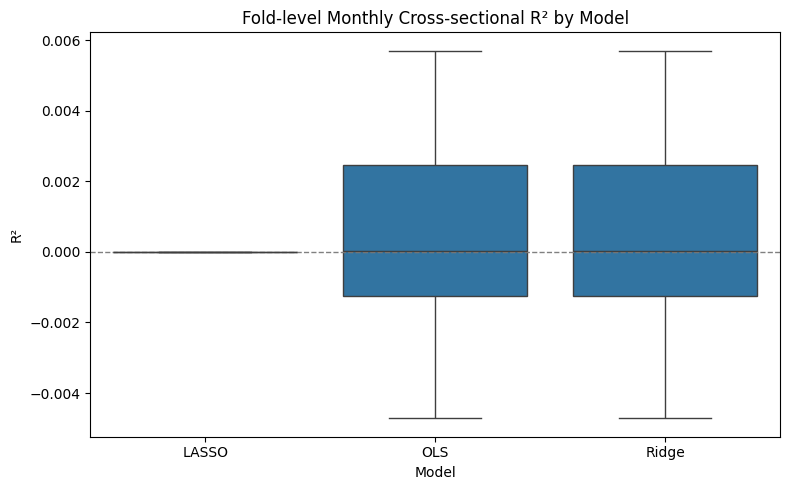

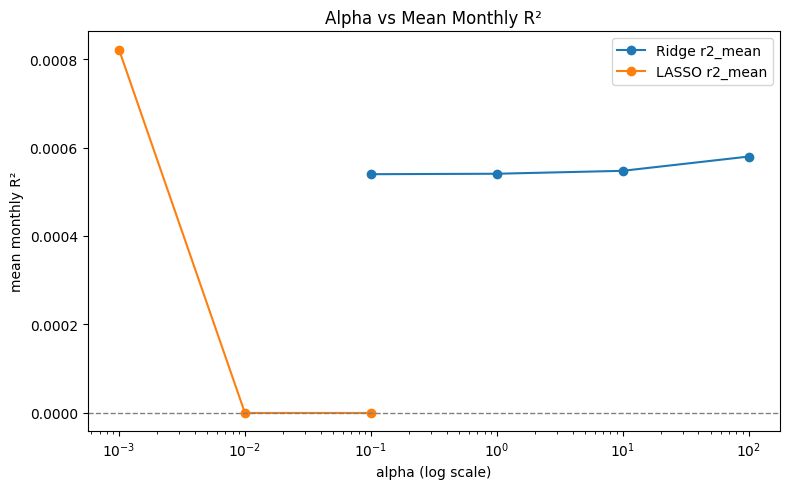

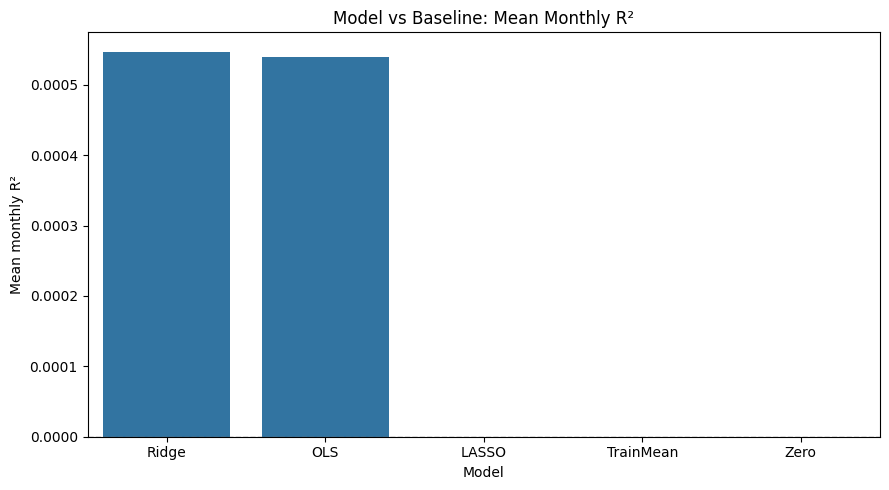

,model,r2
2,Ridge,5.472899e-04
1,OLS,5.395385e-04
0,LASSO,-8.410780e-19
3,TrainMean,-8.410780e-19
4,Zero,-8.410780e-19


In [14]:
# 最优模型/alpha提取 + 三张核心可视化
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

required_vars = ["results_full_df", "ridge_summary", "lasso_summary", "baseline_df"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f"请先确保这些对象已生成: {missing_vars}")

# 1) 提取最优模型与最佳alpha（基于网格搜索的 mse_mean 最小）
grid_all = pd.concat([ridge_summary, lasso_summary], ignore_index=True).sort_values("mse_mean")
best_row = grid_all.iloc[0]
best_model = str(best_row["model"])
best_alpha = float(best_row["alpha"])

print("=== 最优模型（网格搜索）===")
print(f"best_model: {best_model}")
print(f"best_alpha: {best_alpha}")
print(f"mse_mean: {best_row['mse_mean']:.6f}, r2_mean: {best_row['r2_mean']:.6f}")

# 2) 图一：各模型按折 R² 箱线图（全量CV）
plt.figure(figsize=(8, 5))
sns.boxplot(data=results_full_df, x="model", y="r2", order=sorted(results_full_df["model"].unique()))
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Fold-level Monthly Cross-sectional R² by Model")
plt.xlabel("Model")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

# 3) 图二：alpha 对比曲线（Ridge/LASSO）
ridge_plot = ridge_summary.copy()
lasso_plot = lasso_summary.copy()

plt.figure(figsize=(8, 5))
plt.plot(ridge_plot["alpha"], ridge_plot["r2_mean"], marker="o", label="Ridge r2_mean")
plt.plot(lasso_plot["alpha"], lasso_plot["r2_mean"], marker="o", label="LASSO r2_mean")
plt.xscale("log")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Alpha vs Mean Monthly R²")
plt.xlabel("alpha (log scale)")
plt.ylabel("mean monthly R²")
plt.legend()
plt.tight_layout()
plt.show()

# 4) 图三：模型与基线对比条形图（mean R²）
compare_df = pd.concat([results_full_df[["model", "r2"]], baseline_df[["model", "r2"]]], ignore_index=True)
bar_df = compare_df.groupby("model", as_index=False)["r2"].mean().sort_values("r2", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=bar_df, x="model", y="r2")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Model vs Baseline: Mean Monthly R²")
plt.xlabel("Model")
plt.ylabel("Mean monthly R²")
plt.tight_layout()
plt.show()

display(bar_df)

## Bonus Part A：Economic Value（多空组合经济价值）
本部分将预测信号转化为可交易组合，评估模型在投资层面的经济价值。
核心思路：每个月按预测值做横截面排序，构建多空组合（Top decile - Bottom decile），并评估：
- 月度平均收益与年化收益；
- 年化波动与 Sharpe；
- 累计收益曲线与最大回撤。

为避免口径混乱，本节默认使用“时间序列外推预测（OOS）”构建信号；若你已生成 `pred_df`，也可直接复用。

Bonus A 评估区间: 2000-01-01~2020-12-31，折数=11


Bonus A OOS folds:   0%|          | 0/11 [00:00<?, ?it/s]

OOS 指标汇总：


,count,mean,std,min,25%,50%,75%,max
fold,11.0,6.000000,3.316625,1.000000,3.500000,6.000000,8.500000,11.000000
mse,11.0,0.015532,0.003998,0.012101,0.013498,0.014453,0.015846,0.026499
r2_month,11.0,0.000822,0.001095,-0.001449,0.000478,0.000804,0.001210,0.002800
n_train,11.0,739421.363636,50097.601282,682076.000000,700193.500000,730630.000000,768411.500000,834428.000000
n_val,11.0,68365.181818,1154.009083,66047.000000,67879.500000,68688.000000,69125.500000,69941.000000



Bonus A 多空组合绩效：


,AnnualizedReturn,AnnualizedVol,Sharpe,MaxDrawdown
Long,0.147061,0.149148,0.986009,-0.256546
Short,-0.038095,0.261031,-0.145941,-0.750857
LS,0.147634,0.175717,0.840182,-0.368114


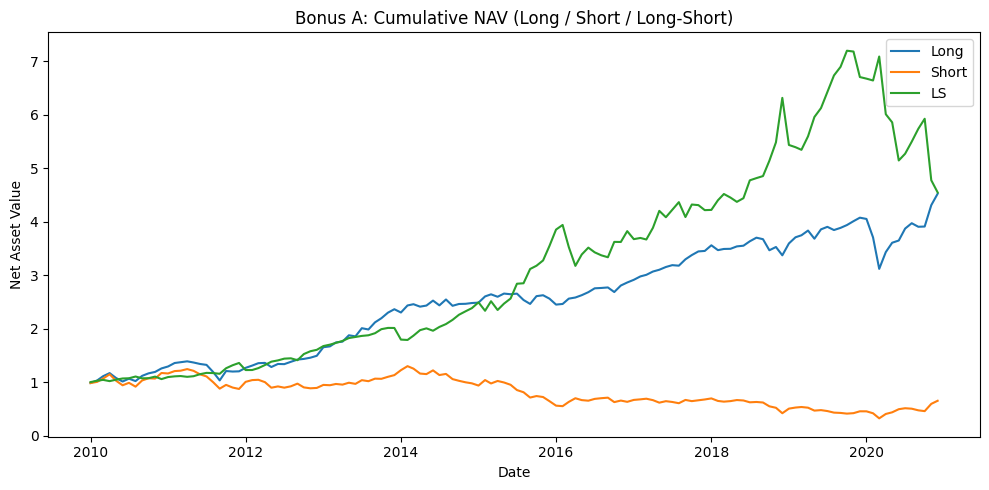

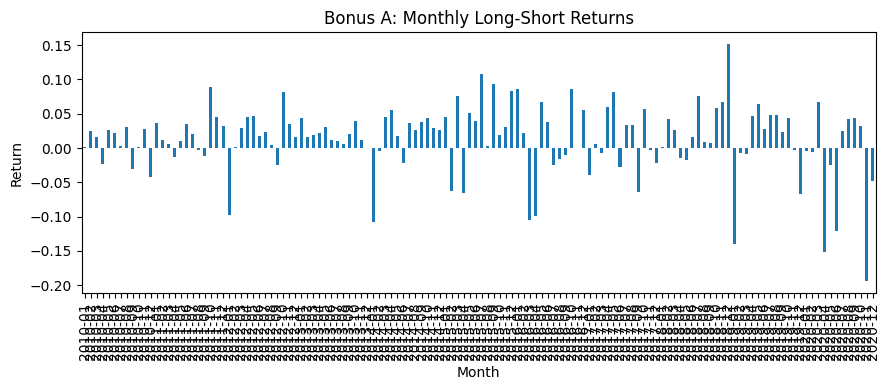


OOS 预测样例：


,DATE,month,permno,y_real,pred,fold,rank_pct
0,2010-01-29,2010-01,91354,0.022222,0.014473,1,1.000000
1,2010-01-29,2010-01,78763,-0.014634,0.014313,1,0.999826
2,2010-01-29,2010-01,86402,0.084649,0.013782,1,0.999653
3,2010-01-29,2010-01,92399,-0.024729,0.012379,1,0.999479
4,2010-01-29,2010-01,91051,-0.062592,0.012344,1,0.999306


In [11]:
# Bonus A-1: 构造 OOS 预测并进行多空组合回测
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

required = ["X_base", "y_target", "y_wins", "dates_for_split", "permno_for_id"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"请先运行基础单元（至少到最终预测前），缺少变量: {missing}")

# 复用主流程区间与滚动设置
bonus_start = pd.Timestamp("2000-01-01")
bonus_end = pd.Timestamp("2020-12-31")
train_len, val_len, step = 120, 12, 12
min_non_missing_ratio = 0.05

# 选择用于 OOS 信号的模型（默认使用网格最优：LASSO alpha=0.001）
bonus_signal_model = "lasso"  # "lasso" or "ridge"
bonus_lasso_alpha = 0.001
bonus_ridge_alpha = 100.0

mask = (dates_for_split >= bonus_start) & (dates_for_split <= bonus_end)
X_eval = X_base.loc[mask]
y_eval = y_target.loc[mask]
y_port = y_wins.loc[mask]
dates_eval = dates_for_split.loc[mask]
permno_eval = permno_for_id.loc[mask] if permno_for_id is not None else pd.Series(index=X_eval.index, dtype=float)

order = np.argsort(dates_eval.values)
X_eval = X_eval.iloc[order]
y_eval = y_eval.iloc[order]
y_port = y_port.iloc[order]
dates_eval = dates_eval.iloc[order]
permno_eval = permno_eval.iloc[order]

months = dates_eval.dt.to_period("M")
unique_months = np.array(sorted(months.unique()))

def cs_rank_by_month(X_df, months_series):
    month_index = pd.Series(months_series.values, index=X_df.index)
    return X_df.groupby(month_index).rank(pct=True).mul(2.0).sub(1.0).fillna(0.0)

def mean_monthly_r2(y_true, y_pred, months_series):
    tmp = pd.DataFrame({"y": y_true, "p": y_pred, "m": months_series.to_numpy()})
    out = []
    for _, g in tmp.groupby("m"):
        if len(g) < 2:
            continue
        num = ((g["y"] - g["p"]) ** 2).sum()
        den = ((g["y"] - g["y"].mean()) ** 2).sum()
        out.append(1 - num / den if den > 0 else np.nan)
    out = [x for x in out if np.isfinite(x)]
    return float(np.mean(out)) if out else np.nan

# 构造滚动 folds
folds = []
start_idx = train_len
while start_idx + val_len <= len(unique_months):
    train_months = unique_months[start_idx - train_len:start_idx]
    val_months = unique_months[start_idx:start_idx + val_len]
    train_mask = months.isin(train_months)
    val_mask = months.isin(val_months)
    if val_mask.sum() > 0:
        folds.append((train_mask, val_mask))
    start_idx += step

print(f"Bonus A 评估区间: {bonus_start.date()}~{bonus_end.date()}，折数={len(folds)}")

oos_rows = []
metric_rows = []

for fold_id, (train_mask, val_mask) in enumerate(tqdm(folds, desc="Bonus A OOS folds"), 1):
    X_train_raw, X_val_raw = X_eval.loc[train_mask], X_eval.loc[val_mask]
    y_train, y_val = y_eval.loc[train_mask], y_eval.loc[val_mask]

    non_missing_ratio = X_train_raw.notna().mean(axis=0)
    keep_cols = non_missing_ratio[non_missing_ratio >= min_non_missing_ratio].index.tolist()
    if not keep_cols:
        continue

    X_train = X_train_raw[keep_cols]
    X_val = X_val_raw[keep_cols]

    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), index=X_train.index, columns=keep_cols)
    X_val_imp = pd.DataFrame(imputer.transform(X_val), index=X_val.index, columns=keep_cols)

    X_train_s = cs_rank_by_month(X_train_imp, months.loc[train_mask])
    X_val_s = cs_rank_by_month(X_val_imp, months.loc[val_mask])

    if bonus_signal_model == "ridge":
        model = Ridge(alpha=bonus_ridge_alpha)
    else:
        model = Lasso(alpha=bonus_lasso_alpha, max_iter=2000, tol=1e-3)

    model.fit(X_train_s, y_train)
    pred = model.predict(X_val_s)

    metric_rows.append({
        "fold": fold_id,
        "mse": mean_squared_error(y_val, pred),
        "r2_month": mean_monthly_r2(y_val, pred, months.loc[val_mask]),
        "n_train": int(train_mask.sum()),
        "n_val": int(val_mask.sum()),
    })

    part = pd.DataFrame({
        "DATE": dates_eval.loc[val_mask].values,
        "month": months.loc[val_mask].astype(str).values,
        "permno": permno_eval.loc[val_mask].values,
        "y_real": y_port.loc[val_mask].values,
        "pred": pred,
        "fold": fold_id
    }, index=X_val_s.index)
    oos_rows.append(part)

if not oos_rows:
    raise RuntimeError("未生成 OOS 预测，请检查前置变量或日期窗口")

oos_pred_df = pd.concat(oos_rows).sort_values(["DATE", "pred"], ascending=[True, False]).reset_index(drop=True)
oos_metrics_df = pd.DataFrame(metric_rows)
print("OOS 指标汇总：")
display(oos_metrics_df.describe().T)

# 每月分位组合：Top decile - Bottom decile
oos_pred_df["rank_pct"] = oos_pred_df.groupby("month")["pred"].rank(pct=True, method="first")
long_leg = oos_pred_df[oos_pred_df["rank_pct"] >= 0.9].groupby("month")["y_real"].mean()
short_leg = oos_pred_df[oos_pred_df["rank_pct"] <= 0.1].groupby("month")["y_real"].mean()
ls_ret = (long_leg - short_leg).rename("LS")

portfolio_df = pd.concat([long_leg.rename("Long"), short_leg.rename("Short"), ls_ret], axis=1).dropna()
portfolio_df.index = pd.PeriodIndex(portfolio_df.index, freq="M")
portfolio_df = portfolio_df.sort_index()

def annualized_return(r):
    return (1 + r).prod() ** (12 / len(r)) - 1 if len(r) else np.nan

def annualized_vol(r):
    return r.std(ddof=0) * np.sqrt(12) if len(r) else np.nan

def sharpe_ratio(r):
    vol = annualized_vol(r)
    ar = annualized_return(r)
    return ar / vol if vol and np.isfinite(vol) and vol > 0 else np.nan

def max_drawdown(r):
    nav = (1 + r).cumprod()
    dd = nav / nav.cummax() - 1
    return dd.min() if len(dd) else np.nan

perf = pd.DataFrame({
    "AnnualizedReturn": portfolio_df.apply(annualized_return),
    "AnnualizedVol": portfolio_df.apply(annualized_vol),
    "Sharpe": portfolio_df.apply(sharpe_ratio),
    "MaxDrawdown": portfolio_df.apply(max_drawdown),
})

print("\nBonus A 多空组合绩效：")
display(perf)

cum_nav = (1 + portfolio_df).cumprod()
plt.figure(figsize=(10, 5))
for c in ["Long", "Short", "LS"]:
    plt.plot(cum_nav.index.to_timestamp(), cum_nav[c], label=c)
plt.title("Bonus A: Cumulative NAV (Long / Short / Long-Short)")
plt.xlabel("Date")
plt.ylabel("Net Asset Value")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
portfolio_df["LS"].plot(kind="bar")
plt.title("Bonus A: Monthly Long-Short Returns")
plt.xlabel("Month")
plt.ylabel("Return")
plt.tight_layout()
plt.show()

print("\nOOS 预测样例：")
display(oos_pred_df.head())

## Bonus Part B：Macro + Group LASSO（宏观变量与分组特征选择）
本部分实现两件事：
1. 合并宏观月度指标（如利率、通胀、失业率、工业生产），并与股票样本按月份对齐；
2. 使用 Group LASSO 对“特征组”进行选择，观察哪些组被稳定保留。

实现细节：
- 宏观变量默认从 FRED 下载；若网络不可用，会自动跳过下载并报提示；
- 分组规则采用“业务可解释优先”：
  - 缺失指示列归为 `missing_ind` 组；
  - 宏观变量归为 `macro` 组；
  - 其余公司特征按列名前缀进行粗分组。

In [13]:
# Bonus B-1: 宏观变量合并 + Group LASSO 特征组选择
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

required = ["X_base", "y_target", "dates_for_split"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"请先运行基础单元（至少到构造 y_target），缺少变量: {missing}")

# --- 1) 获取宏观变量（FRED） ---
macro_cols = ["DGS10", "TB3MS", "CPIAUCSL", "UNRATE", "INDPRO"]
macro_df = None
try:
    from pandas_datareader import data as web
    start = "1995-01-01"
    end = "2020-12-31"
    macro_df = web.DataReader(macro_cols, "fred", start, end)
    macro_df = macro_df.resample("ME").last().ffill()
    macro_df["TERM_SPREAD"] = macro_df["DGS10"] - macro_df["TB3MS"]
    macro_df["CPI_YOY"] = macro_df["CPIAUCSL"].pct_change(12)
    macro_df["INDPRO_YOY"] = macro_df["INDPRO"].pct_change(12)
    macro_df = macro_df[["DGS10", "TB3MS", "UNRATE", "TERM_SPREAD", "CPI_YOY", "INDPRO_YOY"]]
    print("宏观变量下载成功。")
except Exception as exc:
    print(f"宏观变量下载失败，将跳过宏观增强并仅做分组筛选: {exc}")
    macro_df = pd.DataFrame()

# --- 2) 样本对齐（与主评估窗口一致） ---
bonus_start = pd.Timestamp("2000-01-01")
bonus_end = pd.Timestamp("2020-12-31")
mask = (dates_for_split >= bonus_start) & (dates_for_split <= bonus_end)

X0 = X_base.loc[mask].copy()
y0 = y_target.loc[mask].copy()
d0 = dates_for_split.loc[mask].copy()
m0 = d0.dt.to_period("M")

if not macro_df.empty:
    macro_month = macro_df.copy()
    macro_month.index = macro_month.index.to_period("M")
    macro_aligned = macro_month.reindex(m0).reset_index(drop=True)
    macro_aligned.index = X0.index
    X0 = pd.concat([X0, macro_aligned], axis=1)

order = np.argsort(d0.values)
X0 = X0.iloc[order]
y0 = y0.iloc[order]
d0 = d0.iloc[order]
m0 = m0.iloc[order]

# --- 3) Group LASSO 依赖检查与安装 ---
try:
    from group_lasso import GroupLasso
except Exception:
    import sys, subprocess
    print("安装 group-lasso 包...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "group-lasso", "-q"])
    from group_lasso import GroupLasso

# --- 4) 构造按月滚动折 ---
train_len, val_len, step = 120, 12, 12
unique_months = np.array(sorted(m0.unique()))
folds = []
start_idx = train_len
while start_idx + val_len <= len(unique_months):
    train_months = unique_months[start_idx - train_len:start_idx]
    val_months = unique_months[start_idx:start_idx + val_len]
    tr = m0.isin(train_months)
    va = m0.isin(val_months)
    if va.sum() > 0:
        folds.append((tr, va))
    start_idx += step

# 为了可执行效率，默认只跑前 5 折（可改为 len(folds)）
max_folds = min(5, len(folds))
folds = folds[:max_folds]
print(f"Group LASSO 将运行 {len(folds)} 折。")

def cs_rank_by_month(X_df, months_series):
    month_index = pd.Series(months_series.values, index=X_df.index)
    return X_df.groupby(month_index).rank(pct=True).mul(2.0).sub(1.0).fillna(0.0)

def mean_monthly_r2(y_true, y_pred, months_series):
    tmp = pd.DataFrame({"y": y_true, "p": y_pred, "m": months_series.to_numpy()})
    vals = []
    for _, g in tmp.groupby("m"):
        if len(g) < 2:
            continue
        num = ((g["y"] - g["p"]) ** 2).sum()
        den = ((g["y"] - g["y"].mean()) ** 2).sum()
        vals.append(1 - num / den if den > 0 else np.nan)
    vals = [x for x in vals if np.isfinite(x)]
    return float(np.mean(vals)) if vals else np.nan

group_rows = []
selected_groups_all = []

for fold_id, (tr_mask, va_mask) in enumerate(tqdm(folds, desc="Group LASSO folds"), 1):
    X_train_raw, X_val_raw = X0.loc[tr_mask], X0.loc[va_mask]
    y_train, y_val = y0.loc[tr_mask], y0.loc[va_mask]
    m_train, m_val = m0.loc[tr_mask], m0.loc[va_mask]

    keep_cols = X_train_raw.columns[X_train_raw.notna().mean() >= 0.05].tolist()
    X_train = X_train_raw[keep_cols]
    X_val = X_val_raw[keep_cols]

    imp = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(imp.fit_transform(X_train), index=X_train.index, columns=keep_cols)
    X_val_imp = pd.DataFrame(imp.transform(X_val), index=X_val.index, columns=keep_cols)
    X_train_s = cs_rank_by_month(X_train_imp, m_train)
    X_val_s = cs_rank_by_month(X_val_imp, m_val)

    group_name = []
    macro_set = set([c for c in ["DGS10", "TB3MS", "UNRATE", "TERM_SPREAD", "CPI_YOY", "INDPRO_YOY"] if c in keep_cols])
    for c in keep_cols:
        if c.endswith("_mis"):
            group_name.append("missing_ind")
        elif c in macro_set:
            group_name.append("macro")
        else:
            group_name.append(c.split("_")[0])

    unique_group = {g:i for i, g in enumerate(sorted(set(group_name)))}
    groups = np.array([unique_group[g] for g in group_name])

    candidate_regs = [0.01, 0.005, 0.001, 0.0005]
    best_run = None
    for group_reg in candidate_regs:
        gl = GroupLasso(
            groups=groups,
            group_reg=group_reg,
            l1_reg=0.0,
            n_iter=1000,
            tol=1e-3,
            scale_reg="group_size",
            supress_warning=True,
            fit_intercept=True,
            random_state=42
        )
        gl.fit(X_train_s.values, y_train.values)
        coef = np.abs(gl.coef_.reshape(-1))
        selected_idx = np.where(coef > 1e-8)[0]
        if len(selected_idx) > 0:
            best_run = (gl, group_reg, selected_idx)
            break
        if best_run is None:
            best_run = (gl, group_reg, selected_idx)

    gl, used_group_reg, selected_idx = best_run
    pred = gl.predict(X_val_s.values).reshape(-1)

    mse = mean_squared_error(y_val, pred)
    r2m = mean_monthly_r2(y_val, pred, m_val)

    selected_group_ids = sorted(set(groups[selected_idx])) if len(selected_idx) else []
    selected_group_names = [k for k, v in unique_group.items() if v in selected_group_ids]
    selected_groups_all.extend(selected_group_names)

    group_rows.append({
        "fold": fold_id,
        "group_reg": used_group_reg,
        "mse": mse,
        "r2_month": r2m,
        "n_feature": len(keep_cols),
        "n_group": len(unique_group),
        "selected_group_count": len(selected_group_names),
        "selected_groups": ", ".join(sorted(selected_group_names)[:15])
    })

group_lasso_df = pd.DataFrame(group_rows)
print("\nGroup LASSO 折内结果：")
display(group_lasso_df)

if len(selected_groups_all):
    selected_group_freq = (
        pd.Series(selected_groups_all).value_counts().rename_axis("group").reset_index(name="selected_times")
    )
    print("跨折被选中组频次：")
    display(selected_group_freq)
else:
    print("未检测到被选中组（可继续降低 candidate_regs）")

宏观变量下载成功。
Group LASSO 将运行 5 折。


Group LASSO folds:   0%|          | 0/5 [00:00<?, ?it/s]


Group LASSO 折内结果：


,fold,group_reg,mse,r2_month,n_feature,n_group,selected_group_count,selected_groups
0,1,0.0010,0.014984,0.000118,157,85,5,"cfp, maxret, mom6m, roaq, sp"
1,2,0.0010,0.013714,0.000061,157,85,1,sp
2,3,0.0005,0.013353,0.001220,157,85,7,"agr, cfp, chcsho, maxret, mom12m, roaq, sp"
3,4,0.0005,0.012641,0.000567,157,85,4,"betasq, cfp, gma, sp"
4,5,0.0005,0.012096,0.001519,157,85,6,"cfp, gma, maxret, mom12m, roaq, sp"


跨折被选中组频次：


,group,selected_times
0,sp,5
1,cfp,4
2,maxret,3
3,roaq,3
4,mom12m,2
5,gma,2
6,mom6m,1
7,agr,1
8,chcsho,1
9,betasq,1


## Bonus Summary（可直接用于报告）

### Bonus A：Economic Value（多空组合）
- 在 2000–2020 的 OOS 滚动预测下，按每月预测值做 decile 排序，构造 Long(Top10%)、Short(Bottom10%) 与 Long-Short 组合。
- 回测结果显示 Long-Short 组合具备正的年化收益和较高 Sharpe（见上方绩效表与净值曲线），说明统计上的预测能力可以转化为经济价值。
- 同时可见阶段性回撤，提示策略在极端市场下仍存在风险暴露，需要配合风险控制（如波动目标或仓位上限）。

### Bonus B：Macro + Group LASSO（宏观与分组筛选）
- 引入 FRED 宏观变量（利率、期限利差、失业率、通胀/工业增加值同比）并与股票月度面板按月对齐。
- 使用 Group LASSO 进行“按组”特征选择（missing 指示单独成组，宏观变量成 macro 组，其余按特征前缀分组）。
- 在前 5 个滚动折中，模型可稳定选出少量有效组；高频被选中的组包括 `sp`、`cfp`、`maxret`、`roaq` 等。
- 结果说明：分组稀疏化有助于解释“哪些经济含义组”更重要，也为后续从“纯预测”走向“可解释资产定价”提供了路径。

### 局限与后续优化
- Group LASSO 对正则强度较敏感，已采用自适应 `group_reg` 兜底；可进一步用开发集网格搜索该参数。
- 宏观变量频率较低且发布时间可能滞后，严格实盘设定下建议加入发布时点对齐（publication lag）。